In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('rock_density_xray.csv')
df.head()

,Rebound Signal Strength nHz,Rock Density kg/m3
0,72.945124,2.456548
1,14.229877,2.601719
2,36.597334,1.967004
3,9.578899,2.300439
4,21.765897,2.452374


In [3]:
df.columns=['Signal','Density']

In [4]:
df.head()

,Signal,Density
0,72.945124,2.456548
1,14.229877,2.601719
2,36.597334,1.967004
3,9.578899,2.300439
4,21.765897,2.452374


<Axes: xlabel='Signal', ylabel='Density'>

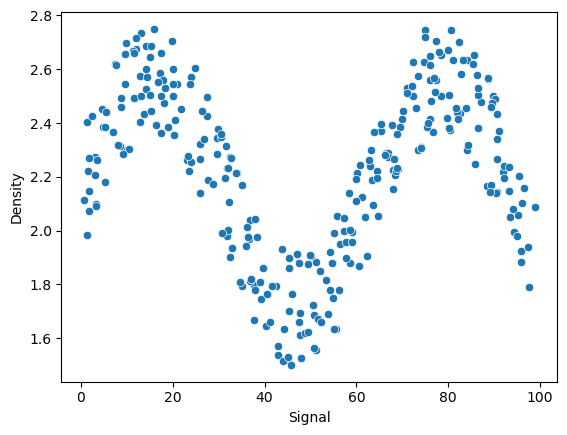

In [5]:
sns.scatterplot(x='Signal',y='Density',data=df)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Signal   300 non-null    float64
 1   Density  300 non-null    float64
dtypes: float64(2)
memory usage: 4.8 KB


In [6]:
X=df['Signal'].values.reshape(-1,1)
y= df['Density']

In [8]:
X #this is now a 2d array

array([[72.94512436],
       [14.2298772 ],
       [36.59733361],
       [ 9.57889939],
       [21.76589708],
       [89.64797256],
       [69.49273293],
       [20.15052036],
       [82.25633703],
       [64.42480217],
       [38.42706534],
       [ 9.89157994],
       [31.7410984 ],
       [90.4960676 ],
       [13.19342555],
       [ 9.55665673],
       [26.00550577],
       [24.81782725],
       [40.29631043],
       [29.60926638],
       [76.57740035],
       [82.61598742],
       [ 1.66229161],
       [17.32519267],
       [35.05157441],
       [63.47748521],
       [13.68823691],
       [17.49779896],
       [ 1.86382485],
       [17.96684624],
       [23.9388581 ],
       [66.36433682],
       [34.02717884],
       [76.03302052],
       [82.66759709],
       [66.78076834],
       [47.4528517 ],
       [74.02752794],
       [86.20473574],
       [72.24767039],
       [80.33899095],
       [36.86719496],
       [31.92883259],
       [85.68535822],
       [78.45459768],
       [19

In [9]:
y

0      2.456548
1      2.601719
2      1.967004
3      2.300439
4      2.452374
         ...   
295    2.112965
296    2.000293
297    1.879181
298    2.644990
299    2.044287
Name: Density, Length: 300, dtype: float64

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.1,random_state=50)

In [13]:
from sklearn.linear_model import LinearRegression

In [14]:
lr_model= LinearRegression()

In [15]:
lr_model.fit(X_train,y_train)

LinearRegression()

In [16]:
lr_pred= lr_model.predict(X_test)

In [17]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

In [18]:
root_mean_squared_error(lr_pred,y_test)

0.2708024932305631

In [19]:
np.mean(df['Density'])

np.float64(2.225062949323796)

In [20]:
mean_absolute_error(lr_pred,y_test)

0.20362770048675963

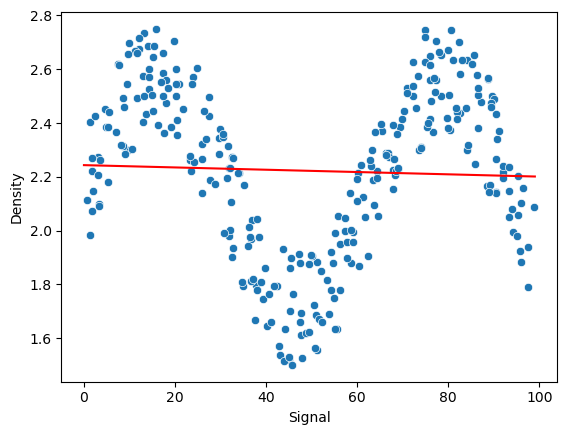

In [21]:
sns.scatterplot(x='Signal',y='Density',data=df)
plt.plot(np.arange(100),lr_model.predict(np.arange(100).reshape(-1,1)),color='red')

### Decision Tree Regressor

In [22]:
from sklearn.tree import DecisionTreeRegressor

In [24]:
model= DecisionTreeRegressor()

In [25]:
model.fit(X_train,y_train)

DecisionTreeRegressor()

In [26]:
pred= model.predict(X_test)

In [27]:
root_mean_squared_error(y_test,pred)

0.1854905015812723

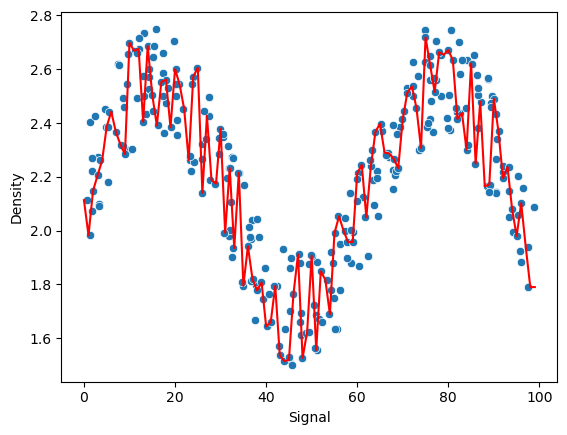

In [28]:
sns.scatterplot(x='Signal',y='Density',data=df)
plt.plot(np.arange(100),model.predict(np.arange(100).reshape(-1,1)),color='red')

In [31]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

In [38]:
param_grid= {'C':[0.01,0.1,1,5,10,1000,10000],
             'gamma':['auto','scale']}

In [39]:
svr=SVR()

In [40]:
grid= GridSearchCV(svr,param_grid)
grid.fit(X_train,y_train)

GridSearchCV(estimator=SVR(),
             param_grid={'C': [0.01, 0.1, 1, 5, 10, 1000, 10000],
                         'gamma': ['auto', 'scale']})

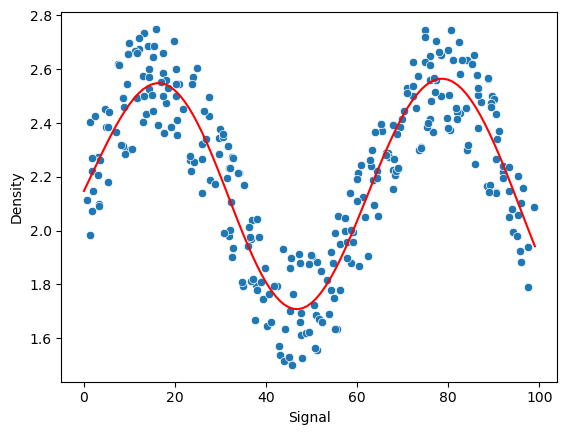

In [41]:
sns.scatterplot(x='Signal',y='Density',data=df)
plt.plot(np.arange(100),grid.predict(np.arange(100).reshape(-1,1)),color='red')

### Random Forest Regression

In [42]:
from sklearn.ensemble import RandomForestRegressor

In [48]:
def execute_model(model, X_train, y_train, X_test,y_test):
    model.fit(X_train,y_train)
    
    preds=model.predict(X_test)
    
    print(f"rmse: {root_mean_squared_error(y_test, preds)}")
    
    signals=np.arange(100)
    output=model.predict(signals.reshape(-1,1))
    
    plt.figure(figsize=(12,6))
    sns.scatterplot(x='Signal',y='Density', data=df,color='blue')
    plt.plot(signals,output)

rmse: 0.15321870443558638
rmse: 0.15237354748097234
rmse: 0.15531796957346825
rmse: 0.14999928533962628


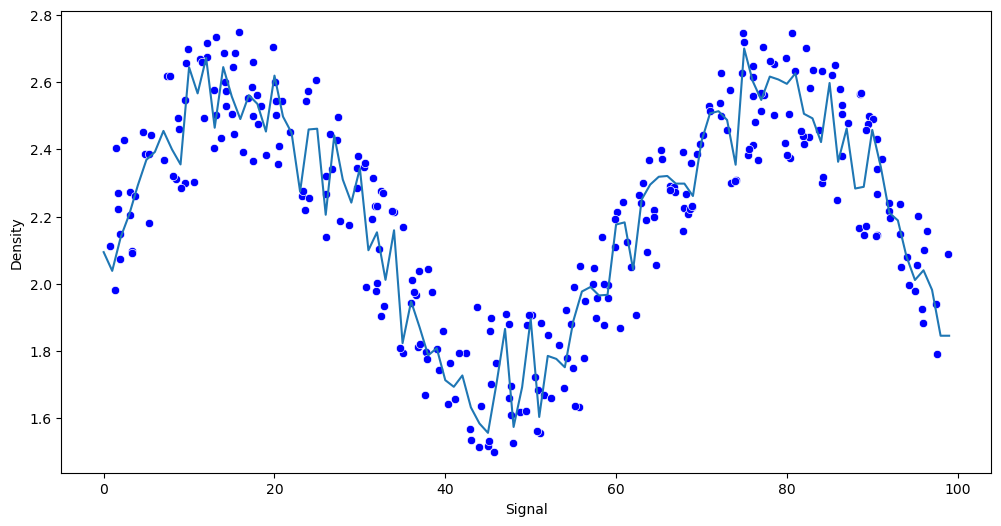

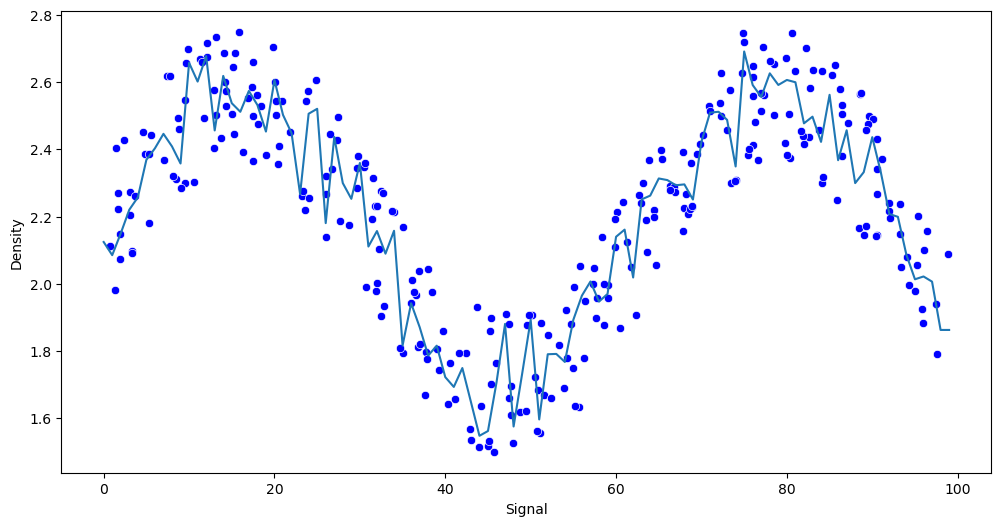

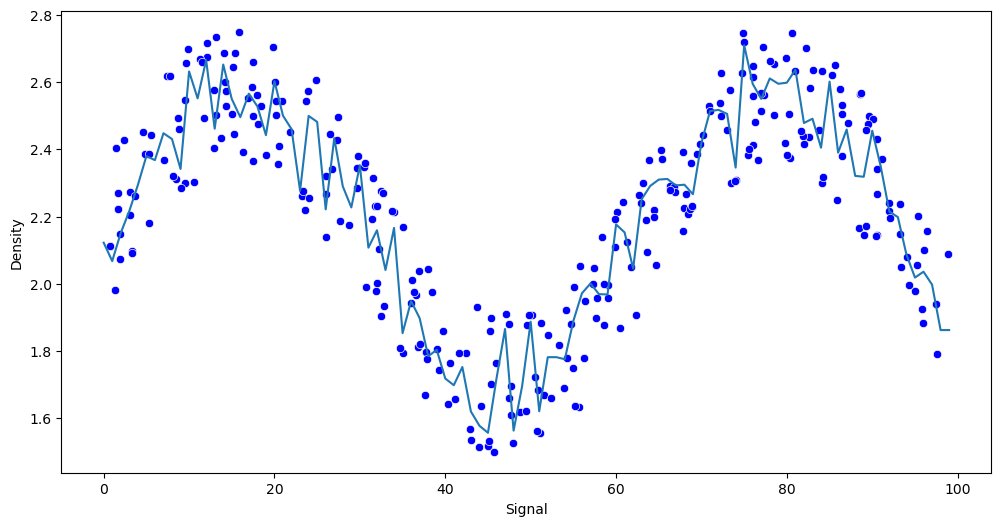

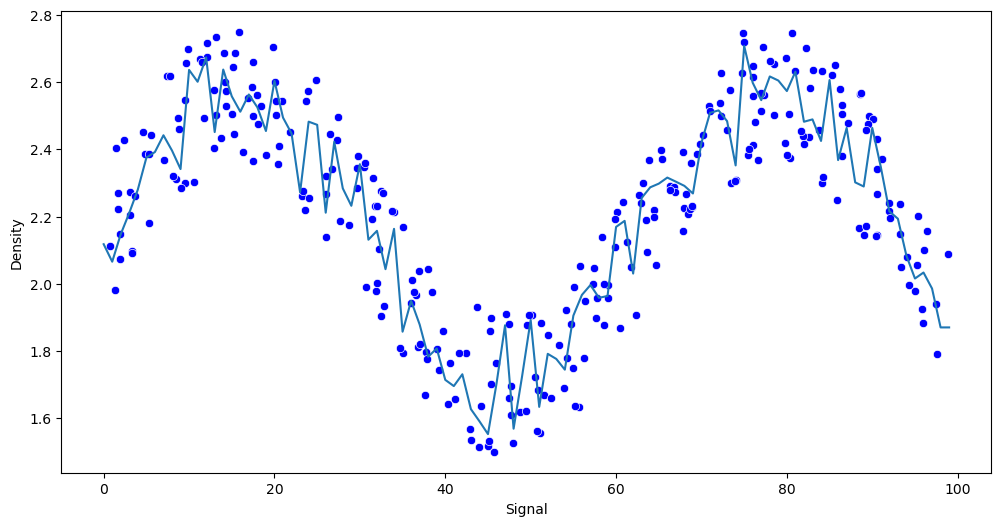

In [51]:
trees= [110,50,100,128]
for n in trees:
    rfr_model=RandomForestRegressor(n_estimators=n)
    execute_model(rfr_model, X_train,y_train, X_test,y_test)
    